# 03. Regresión logística como modelo baseline

El objetivo de este notebook es construir un primer modelo **sencillo, interpretable y reproducible** para estimar la probabilidad de lesión grave o mortal. Se comparan un clasificador trivial, una regresión logística estándar y otra con ponderación de clases.

La división es temporal: 2019–2023 para entrenamiento, 2024 para validación y 2025 como test final. **En este notebook no se consulta el rendimiento en 2025**, para evitar adaptar decisiones al conjunto de test.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, average_precision_score,
    brier_score_loss, f1_score, fbeta_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, RocCurveDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tfm_accidentes.config import PROCESSED_DATA_DIR
from tfm_accidentes.data import read_analysis_table
from tfm_accidentes.features import add_cyclical_features

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

## 1. Carga y división temporal

Se eliminan únicamente los 13 casos con lesividad desconocida. Las variables cíclicas representan correctamente que, por ejemplo, las 23:00 están cerca de las 00:00. Esta transformación es fija y no aprende información de ningún periodo.

In [2]:
data_path = PROCESSED_DATA_DIR / 'accidentes_madrid_2019_2025.csv.gz'
data = read_analysis_table(data_path)
data = data.loc[data['lesion_grave'].notna()].copy()
data['lesion_grave'] = data['lesion_grave'].astype('int8')
data = add_cyclical_features(data)

train = data.loc[data['anio'].between(2019, 2023)].copy()
validation = data.loc[data['anio'].eq(2024)].copy()
test = data.loc[data['anio'].eq(2025)].copy()  # Se reserva; no se evalúa aquí.

split_summary = pd.DataFrame({
    'periodo': ['Entrenamiento (2019-2023)', 'Validación (2024)', 'Test reservado (2025)'],
    'filas': [len(train), len(validation), len(test)],
    'positivos': [train['lesion_grave'].sum(), validation['lesion_grave'].sum(), test['lesion_grave'].sum()],
    'prevalencia': [train['lesion_grave'].mean(), validation['lesion_grave'].mean(), test['lesion_grave'].mean()],
})
assert set(train['anio'].unique()).isdisjoint(validation['anio'].unique())
assert set(validation['anio'].unique()).isdisjoint(test['anio'].unique())
display(split_summary.assign(prevalencia=split_summary['prevalencia'].map('{:.2%}'.format)))

,periodo,filas,positivos,prevalencia
0,Entrenamiento (2019-2023),221899,2706,1.22%
1,Validación (2024),49338,597,1.21%
2,Test reservado (2025),51067,493,0.97%


## 2. Variables y preprocesamiento

No se usan `cod_lesividad` (define el objetivo), identificadores, coordenadas ni fechas crudas. Las categorías desconocidas se imputan como `No consta`; el *one-hot encoding* ignora categorías futuras y agrupa las muy infrecuentes. Todo preprocesamiento que aprende parámetros se ajusta exclusivamente con entrenamiento mediante un `Pipeline`.

In [4]:
categorical_features = [
    'distrito', 'tipo_accidente', 'estado_meteorologico', 'tipo_vehiculo',
    'tipo_persona', 'rango_edad', 'sexo',
]
numeric_features = [
    'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos',
    'es_fin_semana', 'es_noche',
]



features = categorical_features + numeric_features

X_train, y_train = train[features], train['lesion_grave']
X_validation, y_validation = validation[features], validation['lesion_grave']

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='No consta')),
    ('one_hot', OneHotEncoder(
        handle_unknown='infrequent_if_exist', min_frequency=100, drop='first', sparse_output=True)),
])
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),])
preprocessor = ColumnTransformer([
    ('categorical', categorical_pipeline, categorical_features),
    ('numeric', numeric_pipeline, numeric_features),])

print(f'{len(features)} variables originales: {len(categorical_features)} categóricas y {len(numeric_features)} numéricas.')

15 variables originales: 7 categóricas y 8 numéricas.


## 3. Modelos de referencia

El `DummyClassifier` asigna a todos los casos la prevalencia observada en entrenamiento. Permite comprobar que el modelo aprende algo más que el desbalance. La versión balanceada de la regresión penaliza más los errores sobre la clase minoritaria.

In [5]:
models = {
    'Dummy (prevalencia)': DummyClassifier(strategy='prior'),
    'Logística estándar': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', LogisticRegression(max_iter=1500, solver='lbfgs', random_state=RANDOM_STATE)),
    ]),
    'Logística balanceada': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', LogisticRegression(
            max_iter=1500, solver='lbfgs', class_weight='balanced', random_state=RANDOM_STATE
        )),
    ]),
}

validation_probabilities = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    validation_probabilities[name] = model.predict_proba(X_validation)[:, 1]
    print(f'Modelo ajustado: {name}')

Modelo ajustado: Dummy (prevalencia)
Modelo ajustado: Logística estándar
Modelo ajustado: Logística balanceada


## 4. Evaluación en 2024

Debido al fuerte desbalance, la métrica principal es **PR-AUC** (*average precision*). ROC-AUC se mantiene como complemento. También se muestran precisión, sensibilidad (*recall*), F1, F2 —que da más peso a detectar positivos— y Brier para estudiar la calidad probabilística.

In [6]:
def classification_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        'PR-AUC': average_precision_score(y_true, probabilities),
        'ROC-AUC': roc_auc_score(y_true, probabilities),
        'Precisión': precision_score(y_true, predictions, zero_division=0),
        'Recall': recall_score(y_true, predictions, zero_division=0),
        'F1': f1_score(y_true, predictions, zero_division=0),
        'F2': fbeta_score(y_true, predictions, beta=2, zero_division=0),
        'Brier': brier_score_loss(y_true, probabilities),
        'Predichos positivos': int(predictions.sum()),
    }

results = pd.DataFrame({
    name: classification_metrics(y_validation, probabilities)
    for name, probabilities in validation_probabilities.items()
}).T
display(results.round(4))

,PR-AUC,ROC-AUC,Precisión,Recall,F1,F2,Brier,Predichos positivos
Dummy (prevalencia),0.0121,0.5000,0.0000,0.0000,0.0000,0.0000,0.0120,0.0
Logística estándar,0.1088,0.9082,0.1875,0.0101,0.0191,0.0124,0.0115,32.0
Logística balanceada,0.1017,0.9129,0.0609,0.8760,0.1138,0.2381,0.1186,8593.0


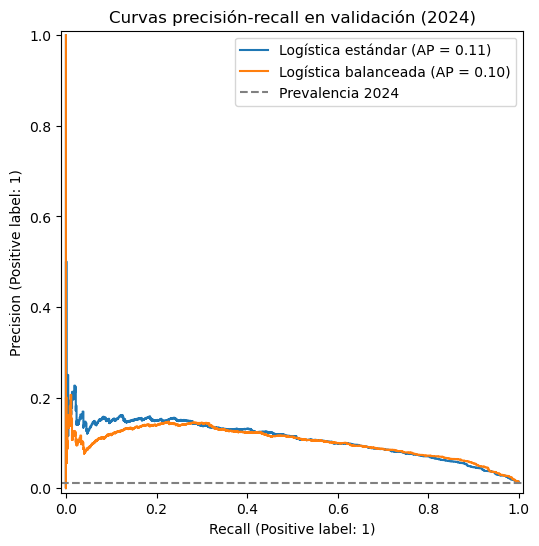

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in ['Logística estándar', 'Logística balanceada']:
    PrecisionRecallDisplay.from_predictions(
        y_validation, validation_probabilities[name], name=name, ax=ax
    )
ax.axhline(y_validation.mean(), color='grey', linestyle='--', label='Prevalencia 2024')
ax.set_title('Curvas precisión-recall en validación (2024)')
ax.legend()
plt.show()

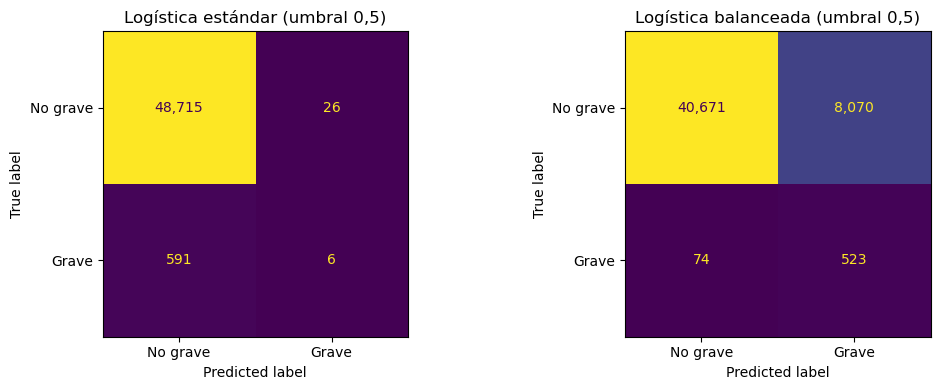

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ['Logística estándar', 'Logística balanceada']):
    predictions = (validation_probabilities[name] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_validation, predictions, display_labels=['No grave', 'Grave'],
        values_format=',d', colorbar=False, ax=ax
    )
    ax.set_title(name + ' (umbral 0,5)')
plt.tight_layout()
plt.show()

La ponderación de clases suele mejorar mucho el *recall* con umbral 0,5, pero sus salidas no deben interpretarse automáticamente como probabilidades bien calibradas. La siguiente figura permite comprobarlo.

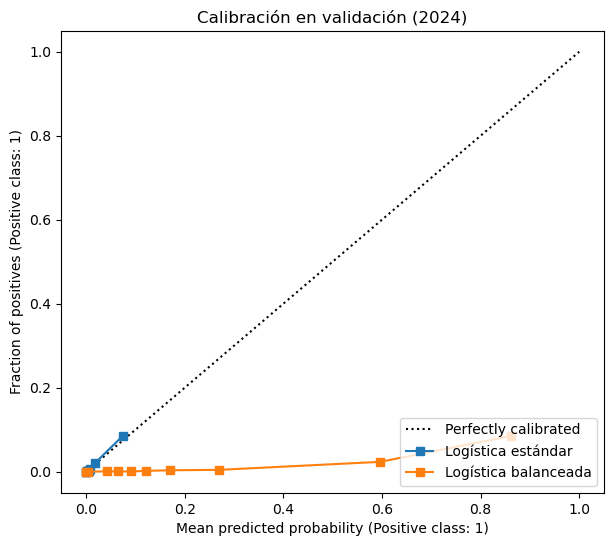

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in ['Logística estándar', 'Logística balanceada']:
    CalibrationDisplay.from_predictions(
        y_validation, validation_probabilities[name], n_bins=10, strategy='quantile',
        name=name, ax=ax
    )
ax.set_title('Calibración en validación (2024)')
plt.show()

## 5. Umbral provisional

Primero se selecciona entre las dos regresiones la de mayor PR-AUC. El umbral 0,5 no es una regla del problema: como ejemplo operativo, se exige detectar al menos el 75 % de las lesiones graves y, entre los umbrales que lo cumplen, se elige el de mayor precisión. Tanto la exigencia como el umbral deberán justificarse en el TFM según el coste de falsos negativos y falsos positivos. Toda la elección se realiza **solo con 2024**.

In [10]:
candidate_names = ['Logística estándar', 'Logística balanceada']
selected_model_name = results.loc[candidate_names, 'PR-AUC'].idxmax()
selected_probabilities = validation_probabilities[selected_model_name]
precision, recall, thresholds = precision_recall_curve(y_validation, selected_probabilities)
target_recall = 0.75
eligible = np.flatnonzero(recall[:-1] >= target_recall)
best_position = eligible[np.argmax(precision[:-1][eligible])]
selected_threshold = float(thresholds[best_position])

threshold_comparison = pd.DataFrame({
    'Umbral 0,5': classification_metrics(y_validation, selected_probabilities, 0.5),
    'Umbral seleccionado': classification_metrics(
        y_validation, selected_probabilities, selected_threshold
    ),
}).T
print(f'Modelo seleccionado por PR-AUC: {selected_model_name}')
print(f'Umbral provisional seleccionado: {selected_threshold:.4f}')
display(threshold_comparison.round(4))

Modelo seleccionado por PR-AUC: Logística estándar
Umbral provisional seleccionado: 0.0245


,PR-AUC,ROC-AUC,Precisión,Recall,F1,F2,Brier,Predichos positivos
"Umbral 0,5",0.1088,0.9082,0.1875,0.0101,0.0191,0.0124,0.0115,32.0
Umbral seleccionado,0.1088,0.9082,0.0770,0.7504,0.1397,0.2730,0.0115,5817.0


## 6. Interpretación del modelo

Los coeficientes indican asociaciones condicionadas al resto de variables, no relaciones causales. En las variables categóricas, un coeficiente positivo aumenta las *odds* estimadas respecto a la categoría de referencia eliminada por `drop='first'`; uno negativo las reduce. En las variables continuas, el cambio corresponde a una desviación estándar.

In [11]:
selected_model = models[selected_model_name]
feature_names = selected_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = pd.DataFrame({
    'variable_transformada': feature_names,
    'coeficiente': selected_model.named_steps['model'].coef_[0],
})
coefficients['odds_ratio'] = np.exp(coefficients['coeficiente'])

display(coefficients.nlargest(15, 'coeficiente'))
display(coefficients.nsmallest(15, 'coeficiente'))

,variable_transformada,coeficiente,odds_ratio
62,categorical__tipo_persona_Peatón,2.331044,10.288680
30,categorical__tipo_accidente_Solo salida de la vía,1.850176,6.360939
50,categorical__tipo_vehiculo_Motocicleta > 125cc,1.473680,4.365271
51,categorical__tipo_vehiculo_Motocicleta hasta 1...,1.133636,3.106933
25,categorical__tipo_accidente_Colisión frontal,1.101205,3.007788
80,categorical__rango_edad_Más de 74 años,1.035410,2.816261
31,categorical__tipo_accidente_Vuelco,0.982944,2.672313
22,categorical__tipo_accidente_Atropello a persona,0.830939,2.295472
24,categorical__tipo_accidente_Choque contra obst...,0.774404,2.169299
46,categorical__tipo_vehiculo_Ciclomotor,0.766125,2.151413


,variable_transformada,coeficiente,odds_ratio
78,categorical__rango_edad_Desconocido,-3.554964,0.028582
36,categorical__estado_meteorologico_No consta,-3.180134,0.041580
55,categorical__tipo_vehiculo_Todo terreno,-1.229178,0.292533
57,categorical__tipo_vehiculo_Turismo,-1.218146,0.295778
44,categorical__tipo_vehiculo_Camión rígido,-1.116880,0.327299
48,categorical__tipo_vehiculo_Furgoneta,-1.031849,0.356348
52,categorical__tipo_vehiculo_No consta,-1.012178,0.363426
29,categorical__tipo_accidente_Otro,-0.848796,0.427930
79,categorical__rango_edad_Menor de 5 años,-0.762551,0.466475
56,categorical__tipo_vehiculo_Tractocamión,-0.694013,0.499567


## 7. Conclusiones y siguiente paso

Este notebook deja fijado el baseline y el protocolo temporal. Las conclusiones deben basarse en PR-AUC, *recall*, precisión, calibración y matrices de confusión, no en *accuracy*.

El siguiente paso será comparar este baseline con un número reducido de modelos no lineales, ajustar hiperparámetros únicamente con 2019–2024 y reservar una sola evaluación final en 2025. Si el modelo elegido necesita probabilidades interpretables, la calibración se incorporará dentro de ese proceso, sin usar el test.